In [21]:
### Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/tom/Projects/gbp_clt/src")

import config as cfg
import distribution_management as dm
import optimisation as opt

In [22]:
### Config

cfg.belief_discretisation = 64
cfg.min_measurement = 0
cfg.max_measurement = 63
cfg.measurement_range = np.linspace(cfg.min_measurement, cfg.max_measurement, cfg.belief_discretisation)
cfg.num_iterations = 20  # unused: chain is solved analytically below

# Chain topology: N variables connected by N-1 pairwise factors,
# with a prior factor on every variable (matches the topology experiment's
# degree=1 setup). All priors are drawn from the same clipped-uniform family
# (homogeneous priors). Heterogeneity is introduced only in the pairwise
# factors.
num_variables = 10
num_edges = num_variables - 1            # 9 pairwise factors
endpoint_idx = 0                         # belief is evaluated at X1 (root analogue)

# Base pairwise kernel width when the chain is homogeneous.
pairwise_width_base = 21

# Heterogeneity sweep: std (in bins) of pairwise widths around the base.
# width_std = 0  → all edges share a single kernel (true homogeneity).
# width_std > 0  → each edge gets its own width drawn from a truncated normal,
#                  and its own additive-noise realisation.
width_stds = np.arange(0, 11, dtype=float)   # 0, 1, 2, ..., 10
min_width = 3
max_width = 41

# R = sigma^2_prior / mean(sigma^2_pairwise) is swept via prior clip_fraction.
clip_fractions = np.linspace(0.01, 0.45, 100)

# Seeds for averaging (mean ± 1σ bands)
seeds = np.arange(1, 1001)

# KL threshold (bits) that defines R*, matching the topology experiment.
# Note: at width=21 and chain length 10, the underlying KL_min is close to
# 0.02 across seeds, so only a fraction of seeds (typically ~5–15%) produce a
# valid R*. The mean R* across valid seeds still tracks the theoretical
# threshold (~5–6); the printed "(N/100 seeds valid)" each iteration tells
# you how many seeds contributed.
kl_threshold_bits = 0.02

# Per-seed smoothing window for the KL-vs-R curve before crossing detection.
# 1 = no smoothing. In this setup smoothing tends to push the smoothed minimum
# above kl_threshold_bits (reducing valid R*), so it is left off by default.
kl_smooth_window = 1

# Noise / floor settings (match other experiments in this repo)
prior_floor = 1e-4
pairwise_floor = 1e-4
prior_noise_strength = 1
pairwise_noise_strength = 1

In [23]:
### Helpers

def create_clipped_uniform(clip_fraction):
    dist = np.ones(cfg.belief_discretisation, dtype=np.float64)
    bins_to_clip = int(clip_fraction * cfg.belief_discretisation)
    if bins_to_clip > 0:
        dist[:bins_to_clip] = 0.0
        dist[-bins_to_clip:] = 0.0
    dist = np.maximum(dist, prior_floor)
    if prior_noise_strength > 0:
        dist += prior_noise_strength * cfg.rng.random(cfg.belief_discretisation)
    return dm.normalise(dist)


def create_narrow_tophat_kernel(width_bins, rng=None):
    if rng is None:
        rng = cfg.rng
    width_bins = int(width_bins)
    k = np.ones(width_bins, dtype=np.float64)
    k = np.maximum(k, pairwise_floor)
    if pairwise_noise_strength > 0:
        k += pairwise_noise_strength * rng.random(width_bins)
    return dm.normalise(k)


def variance_from_distribution(dist, x):
    m = np.sum(dist * x)
    return np.sum(dist * (x - m) ** 2)


def variance_of_pairwise_kernel(kernel_1d):
    bin_width = (cfg.max_measurement - cfg.min_measurement) / (cfg.belief_discretisation - 1)
    offsets = (np.arange(len(kernel_1d)) - (len(kernel_1d) // 2)) * bin_width
    return variance_from_distribution(kernel_1d, offsets)


def sample_pairwise_widths(num_edges, base_width, width_std, rng,
                           lo=None, hi=None):
    """Sample one integer pairwise-kernel width per chain edge.

    width_std == 0 returns identical widths for every edge (homogeneous baseline).
    width_std > 0 draws each width from a Normal(base_width, width_std) truncated
    to [lo, hi].
    """
    if lo is None: lo = min_width
    if hi is None: hi = max_width
    if width_std <= 0:
        return np.full(num_edges, int(base_width), dtype=int)

    widths = np.empty(num_edges, dtype=int)
    for i in range(num_edges):
        for _ in range(1000):
            w = int(round(rng.normal(loc=base_width, scale=width_std)))
            if lo <= w <= hi:
                widths[i] = w
                break
        else:
            widths[i] = int(np.clip(base_width, lo, hi))
    return widths


def build_chain_kernels(widths, rng):
    """Build one pairwise kernel per edge.

    If all sampled widths are identical (the homogeneous case) the same kernel
    is shared across every edge, so there is no residual edge-to-edge
    heterogeneity from additive noise. Otherwise each edge receives its own
    kernel with its own additive-noise realisation.
    """
    if len(set(int(w) for w in widths)) == 1:
        k = create_narrow_tophat_kernel(int(widths[0]), rng=rng)
        return [k for _ in range(len(widths))]
    return [create_narrow_tophat_kernel(int(w), rng=rng) for w in widths]


def chain_belief_at_endpoint(prior, kernels):
    """Exact belief at the endpoint X_0 of a chain X_0 — X_1 — ... — X_{N-1},
    with the same `prior` at every variable. `kernels[i]` is the pairwise
    kernel on edge X[i]↔X[i+1].

    Implemented as the leaf→root inward pass used in the topology experiment
    for degree=1 trees:
        A_{N-1} = prior                                  (far end)
        A_i     = prior * (A_{i+1} ⊛ k_i)                (1 ≤ i ≤ N-2)
        belief(X_0) = prior * (A_1 ⊛ k_0)
    """
    num_edges_local = len(kernels)
    msg = dm.normalise(prior.astype(np.float64).copy())  # A_{N-1}
    log_prior = np.log(np.maximum(prior, 1e-300))
    log_msg = np.log(np.maximum(msg, 1e-300))

    # Walk from edge num_edges_local-1 down to 1: builds A_i for i = N-2 .. 1
    for i in range(num_edges_local - 1, 0, -1):
        incoming = np.convolve(np.exp(log_msg), kernels[i], mode='same')
        incoming = dm.normalise(incoming)
        log_msg = log_prior + np.log(np.maximum(incoming, 1e-300))
        log_msg = log_msg - np.max(log_msg)
        msg_lin = dm.normalise(np.exp(log_msg))
        log_msg = np.log(np.maximum(msg_lin, 1e-300))

    incoming_at_0 = np.convolve(np.exp(log_msg), kernels[0], mode='same')
    incoming_at_0 = dm.normalise(incoming_at_0)
    belief = prior * incoming_at_0
    return dm.normalise(belief)


def kl_to_best_gaussian_bits(belief):
    kl_nats, _, _ = opt.optimise_gaussian_kl(belief, cfg.measurement_range)
    return kl_nats / np.log(2.0)


def smooth_1d(y, window=1):
    """Centred moving average with reflect padding. window must be odd; window=1 is a no-op."""
    if window <= 1:
        return np.asarray(y, dtype=float)
    if window % 2 == 0:
        window += 1
    half = window // 2
    y = np.asarray(y, dtype=float)
    padded = np.pad(y, half, mode='reflect')
    kernel = np.ones(window) / window
    return np.convolve(padded, kernel, mode='valid')


def compute_r_star(R_values, kl_values_bits, threshold_bits,
                   direction='auto', smooth_window=1):
    """R* = first R (after sorting by R) at which KL crosses the threshold.

    With prior_noise_strength > 0 each clip_fraction produces an independent
    noise realisation, so the per-seed KL-vs-R curve is jagged. Setting
    `smooth_window > 1` applies a centred moving average to KL before
    crossing detection — recommended for noisy curves.

    direction='decreasing' (KL high at low R, low at high R) is the usual
    case here: R* is then the smallest R for which KL ≤ threshold.
    """
    R = np.asarray(R_values, dtype=float)
    KL = np.asarray(kl_values_bits, dtype=float)
    order = np.argsort(R)
    R = R[order]; KL = KL[order]
    KL_s = smooth_1d(KL, window=smooth_window)

    if direction == 'auto':
        direction = 'decreasing' if KL_s[-1] < KL_s[0] else 'increasing'

    if direction == 'increasing':
        idx = np.where(KL_s >= threshold_bits)[0]
    else:
        idx = np.where(KL_s <= threshold_bits)[0]
    return R[idx[0]] if idx.size else np.nan

In [24]:
### Main experiment: sweep R* vs pairwise-factor heterogeneity
#
# For each (heterogeneity level width_std, seed):
#   1. Sample 9 pairwise widths around pairwise_width_base from a truncated
#      normal with std=width_std. At width_std=0 all edges share a single
#      kernel.
#   2. Build a kernel per edge (with additive noise).
#   3. Sweep R by varying clip_fraction of the (identical) prior used at
#      every variable in the chain. For each clip_fraction, compute the
#      belief at the endpoint X_1 analytically (inward pass) and its KL
#      to the best-fit Gaussian.
#   4. R* = first R at which the (lightly smoothed) KL drops below
#      kl_threshold_bits.
#
# Priors are pre-generated per (seed, clip_fraction) so all heterogeneity
# levels see identical priors — differences in R* across width_stds therefore
# reflect the effect of pairwise heterogeneity alone.

# --- pre-generate priors reused across heterogeneity levels ---
prior_by_seed_clip = {}
sigma2_prior_by_seed_clip = {}
for seed in seeds:
    cfg.rng = np.random.default_rng(seed=int(seed))
    for cf_idx, cf in enumerate(clip_fractions):
        prior = create_clipped_uniform(cf)
        prior_by_seed_clip[(int(seed), cf_idx)] = prior
        sigma2_prior_by_seed_clip[(int(seed), cf_idx)] = variance_from_distribution(
            prior, cfg.measurement_range
        )

# --- main sweep ---
rstar_by_h = {float(h): np.full(len(seeds), np.nan) for h in width_stds}
KL_curve_by_h_seed = {}              # for optional diagnostic plots
widths_by_h_seed = {}                # for diagnostics
mean_rstar_by_h = {}
std_rstar_by_h = {}

for h in width_stds:
    h_val = float(h)
    for s_idx, seed in enumerate(seeds):
        seed_int = int(seed)
        kernel_rng = np.random.default_rng(
            seed=seed_int * 1000 + int(round(h_val * 10)) + 7
        )
        widths = sample_pairwise_widths(num_edges, pairwise_width_base, h_val, kernel_rng)
        kernels = build_chain_kernels(widths, kernel_rng)
        widths_by_h_seed[(h_val, seed_int)] = widths

        sigma2_pairwise_mean = float(
            np.mean([variance_of_pairwise_kernel(k) for k in kernels])
        )

        R_values = np.empty(len(clip_fractions))
        KL_values = np.empty(len(clip_fractions))
        for cf_idx, _ in enumerate(clip_fractions):
            prior = prior_by_seed_clip[(seed_int, cf_idx)]
            sigma2_prior = sigma2_prior_by_seed_clip[(seed_int, cf_idx)]
            belief = chain_belief_at_endpoint(prior, kernels)
            KL_values[cf_idx] = kl_to_best_gaussian_bits(belief)
            R_values[cf_idx] = (
                sigma2_prior / sigma2_pairwise_mean if sigma2_pairwise_mean > 0 else np.nan
            )

        KL_curve_by_h_seed[(h_val, seed_int)] = (R_values.copy(), KL_values.copy())

        rstar_by_h[h_val][s_idx] = compute_r_star(
            R_values, KL_values, kl_threshold_bits,
            direction='auto', smooth_window=kl_smooth_window
        )

    mean_rstar_by_h[h_val] = float(np.nanmean(rstar_by_h[h_val]))
    std_rstar_by_h[h_val] = float(np.nanstd(rstar_by_h[h_val]))
    valid = int(np.sum(~np.isnan(rstar_by_h[h_val])))
    print(
        f"width_std = {h_val:5.2f}  →  R* = {mean_rstar_by_h[h_val]:.4f} "
        f"± {std_rstar_by_h[h_val]:.4f}   ({valid}/{len(seeds)} seeds valid)"
    )

print('Experiment complete.')

width_std =  0.00  →  R* = 5.4786 ± 1.1461   (58/1000 seeds valid)
width_std =  1.00  →  R* = 5.6077 ± 1.3163   (47/1000 seeds valid)
width_std =  2.00  →  R* = 5.5441 ± 1.2636   (52/1000 seeds valid)
width_std =  3.00  →  R* = 5.6746 ± 1.2729   (52/1000 seeds valid)
width_std =  4.00  →  R* = 5.7456 ± 1.6018   (44/1000 seeds valid)
width_std =  5.00  →  R* = 5.5342 ± 1.3452   (58/1000 seeds valid)
width_std =  6.00  →  R* = 5.4741 ± 1.4647   (46/1000 seeds valid)
width_std =  7.00  →  R* = 5.6297 ± 1.4555   (59/1000 seeds valid)
width_std =  8.00  →  R* = 5.8055 ± 2.0038   (49/1000 seeds valid)
width_std =  9.00  →  R* = 5.4178 ± 1.5738   (41/1000 seeds valid)
width_std = 10.00  →  R* = 5.4589 ± 1.4363   (43/1000 seeds valid)
Experiment complete.


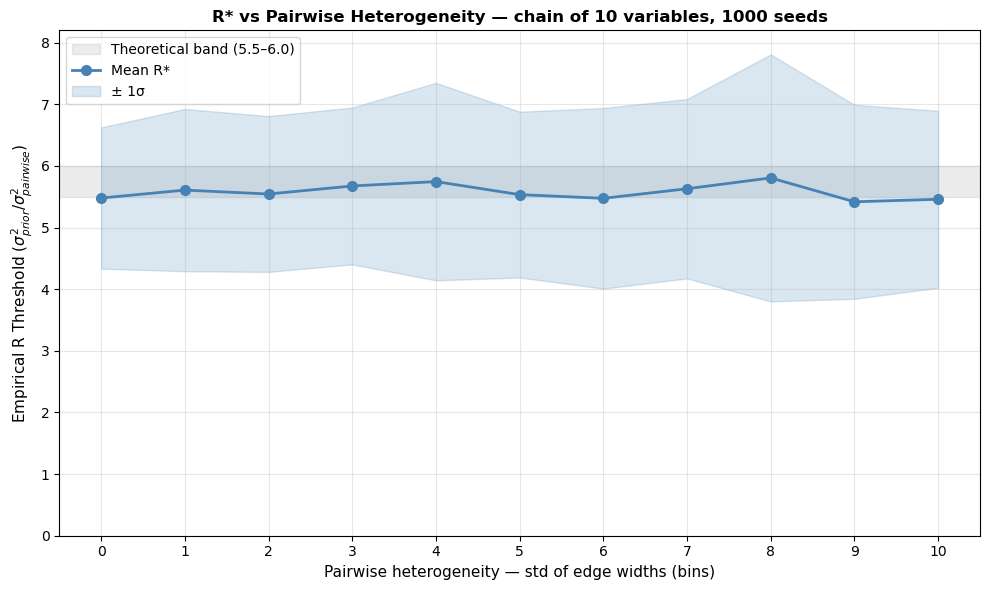

In [25]:
### Plot: R* vs pairwise-factor heterogeneity

xs = np.array(sorted(mean_rstar_by_h.keys()))
means = np.array([mean_rstar_by_h[h] for h in xs])
stds = np.array([std_rstar_by_h[h] for h in xs])

fig, ax = plt.subplots(figsize=(10, 6))

# Reference band for the theoretical R threshold from Lemma 4.2
ax.axhspan(5.5, 6.0, color='grey', alpha=0.15, label='Theoretical band (5.5–6.0)')

ax.plot(xs, means, 'o-', color='steelblue', linewidth=2, markersize=7, label='Mean R*')
ax.fill_between(xs, means - stds, means + stds, color='steelblue', alpha=0.2, label='± 1σ')

ax.set_xlabel('Pairwise heterogeneity — std of edge widths (bins)', fontsize=11)
ax.set_ylabel('Empirical R Threshold ($\\sigma^2_{prior} / \\sigma^2_{pairwise}$)', fontsize=11)
ax.set_title(
    f'R* vs Pairwise Heterogeneity — chain of {num_variables} variables, '
    f'{len(seeds)} seeds',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(xs)
ax.set_ylim(0, max(8.0, float(np.nanmax(means + stds)) * 1.05))
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [26]:
### Loopy experiment: same setup but X_{N-1} is also connected to X_0
#
# This is a ring of `num_variables` variables with `num_variables` pairwise
# factors (one more than the chain). Beliefs are computed with loopy BP rather
# than the exact chain inward pass.
#
# We reuse the same priors (prior_by_seed_clip) and the same width-sampling
# function used in the chain experiment so the chain and loopy results are
# directly comparable. For each (h, seed) the factor graph is built once and
# the prior factor functions are swapped in-place as we sweep clip_fraction.

import factor_graph as fg
import belief_propagation as bp


def build_ring_with_dummy_priors(num_vars, kernels):
    """Build the ring topology with uniform placeholder priors and return the
    graph plus a list of the prior factor nodes (so the caller can update
    each prior's `.function` per clip_fraction without rebuilding the graph).
    `kernels[i]` is used on edge (i, (i+1) % num_vars).
    """
    graph = fg.FactorGraph()
    graph.add_variables(num_vars, cfg.belief_discretisation)
    for i in range(num_vars):
        u = graph.variables[i]
        v = graph.variables[(i + 1) % num_vars]
        pairwise_function = dm.create_smoothing_factor_distribution(
            cfg.belief_discretisation, kernel=kernels[i]
        )
        graph.add_factor([u, v], function=pairwise_function, factor_type='smoothing')
    dummy_prior = np.ones(cfg.belief_discretisation) / cfg.belief_discretisation
    prior_factors = [
        graph.add_factor([var], dummy_prior.copy(), factor_type='prior')
        for var in graph.variables
    ]
    return graph, prior_factors


ring_num_edges = num_variables          # 10 edges (one more than the chain)
ring_endpoint_idx = endpoint_idx        # belief evaluated at X_0 (same as chain)

ring_rstar_by_h = {float(h): np.full(len(seeds), np.nan) for h in width_stds}
ring_mean_rstar_by_h = {}
ring_std_rstar_by_h = {}

for h in width_stds:
    h_val = float(h)
    for s_idx, seed in enumerate(seeds):
        seed_int = int(seed)
        kernel_rng = np.random.default_rng(
            seed=seed_int * 1000 + int(round(h_val * 10)) + 7
        )
        widths = sample_pairwise_widths(ring_num_edges, pairwise_width_base, h_val, kernel_rng)
        kernels = build_chain_kernels(widths, kernel_rng)
        sigma2_pairwise_mean = float(
            np.mean([variance_of_pairwise_kernel(k) for k in kernels])
        )

        graph, prior_factors = build_ring_with_dummy_priors(num_variables, kernels)

        R_values = np.empty(len(clip_fractions))
        KL_values = np.empty(len(clip_fractions))
        for cf_idx, _ in enumerate(clip_fractions):
            prior = prior_by_seed_clip[(seed_int, cf_idx)]
            sigma2_prior = sigma2_prior_by_seed_clip[(seed_int, cf_idx)]
            for pf in prior_factors:
                pf.function = prior
            graph = bp.run_belief_propagation(graph, num_iterations=cfg.num_iterations)
            belief = graph.variables[ring_endpoint_idx].belief
            KL_values[cf_idx] = kl_to_best_gaussian_bits(belief)
            R_values[cf_idx] = (
                sigma2_prior / sigma2_pairwise_mean if sigma2_pairwise_mean > 0 else np.nan
            )

        ring_rstar_by_h[h_val][s_idx] = compute_r_star(
            R_values, KL_values, kl_threshold_bits,
            direction='auto', smooth_window=kl_smooth_window
        )

    ring_mean_rstar_by_h[h_val] = float(np.nanmean(ring_rstar_by_h[h_val]))
    ring_std_rstar_by_h[h_val] = float(np.nanstd(ring_rstar_by_h[h_val]))
    valid = int(np.sum(~np.isnan(ring_rstar_by_h[h_val])))
    print(
        f"width_std = {h_val:5.2f}  →  R*(ring) = {ring_mean_rstar_by_h[h_val]:.4f} "
        f"± {ring_std_rstar_by_h[h_val]:.4f}   ({valid}/{len(seeds)} seeds valid)"
    )

print('Ring experiment complete.')

width_std =  0.00  →  R*(ring) = 5.1187 ± 0.3026   (475/1000 seeds valid)
width_std =  1.00  →  R*(ring) = 5.1182 ± 0.3142   (471/1000 seeds valid)
width_std =  2.00  →  R*(ring) = 5.1340 ± 0.4054   (476/1000 seeds valid)
width_std =  3.00  →  R*(ring) = 5.1183 ± 0.5354   (482/1000 seeds valid)
width_std =  4.00  →  R*(ring) = 5.0961 ± 0.6116   (464/1000 seeds valid)
width_std =  5.00  →  R*(ring) = 5.0917 ± 0.8517   (449/1000 seeds valid)
width_std =  6.00  →  R*(ring) = 5.0683 ± 0.9164   (426/1000 seeds valid)
width_std =  7.00  →  R*(ring) = 5.0759 ± 1.1090   (410/1000 seeds valid)
width_std =  8.00  →  R*(ring) = 5.0251 ± 1.1336   (373/1000 seeds valid)
width_std =  9.00  →  R*(ring) = 4.9129 ± 1.1445   (374/1000 seeds valid)
width_std = 10.00  →  R*(ring) = 4.9875 ± 1.2916   (349/1000 seeds valid)
Ring experiment complete.


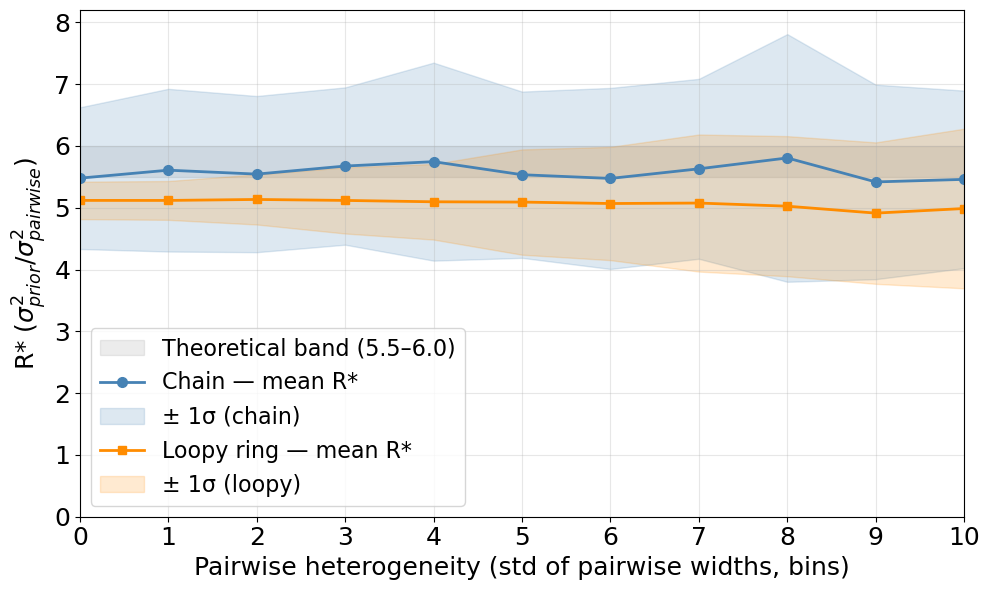

In [ ]:
### Overlay plot: chain vs loopy ring R* across heterogeneity

AXIS_FONT = 18
TICK_FONT = 18
LEGEND_FONT = 16


xs = np.array(sorted(mean_rstar_by_h.keys()))
chain_means = np.array([mean_rstar_by_h[h] for h in xs])
chain_stds = np.array([std_rstar_by_h[h] for h in xs])
ring_means = np.array([ring_mean_rstar_by_h[h] for h in xs])
ring_stds = np.array([ring_std_rstar_by_h[h] for h in xs])

fig, ax = plt.subplots(figsize=(10, 6))
ax.axhspan(5.5, 6.0, color='grey', alpha=0.15, label='Theoretical band (5.5–6.0)')

ax.plot(xs, chain_means, 'o-', color='steelblue', linewidth=2, markersize=7,
        label='Chain — mean R*')
ax.fill_between(xs, chain_means - chain_stds, chain_means + chain_stds,
                color='steelblue', alpha=0.18, label='± 1σ (chain)')

ax.plot(xs, ring_means, 's-', color='darkorange', linewidth=2, markersize=6,
        label='Loopy ring — mean R*')
ax.fill_between(xs, ring_means - ring_stds, ring_means + ring_stds,
                color='darkorange', alpha=0.18, label='± 1σ (loopy)')

ax.set_xlabel('Pairwise heterogeneity (std of pairwise widths, bins)', fontsize=AXIS_FONT)
ax.set_xbound(0, 10)
ax.set_ylabel('R* ($\\sigma^2_{prior} / \\sigma^2_{pairwise}$)', fontsize=AXIS_FONT)
# ax.set_title(
#     f'R* vs Pairwise Heterogeneity — chain vs loopy ring '
#     f'({num_variables} variables, {len(seeds)} seeds)',
#     fontsize=12, fontweight='bold'
# )
ax.set_xticks(xs)
ax.tick_params(axis='both', labelsize=TICK_FONT)
upper = float(np.nanmax(np.concatenate([chain_means + chain_stds, ring_means + ring_stds])))
ax.set_ylim(0, max(8.0, upper * 1.05))
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=LEGEND_FONT)
plt.tight_layout()
plt.show()